# Final submission: December predictions, official scorer and report

This notebook executes the remaining local submission workflow using the saved final CatBoost pipeline from notebook 04. It generates both official CSVs, runs the supplied scorer, displays the exact December chart and rebuilds the PDF report. It does not tune a model or claim hidden-target accuracy.

**Before running:** install `requirements.txt` and `requirements-report.txt`; run notebook 04 if the final model is missing. Select the **Python (spotter)** kernel. `readme-spotter.md`, all supplied CSVs and the earlier model artifacts are preserved.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image, FileLink
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'freight_model.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from complete_submission import prepare_predictions, run_scorer, sha256
from freight_model import source_hashes
from build_report import build_report
from pypdf import PdfReader
protected = {p: sha256(p) for folder in ['catboost', 'xgboost', 'ffn', 'comparison', 'final_catboost']
             for p in (ROOT / 'outputs' / folder).rglob('*') if p.is_file()}
source_before = source_hashes(ROOT)
readme_path = ROOT / 'readme-spotter.md'
readme_before = sha256(readme_path) if readme_path.exists() else None
print('Project:', ROOT)
print('Earlier model/result files protected:', len(protected))

Project: C:\Users\default.LAPTOP-H1OG6SJ2\Desktop\Projects\spotter
Earlier model/result files protected: 49


## 1. Predict both input files

`prepare_predictions` loads the trusted `outputs/final_catboost/pipeline.joblib` fitted on all 48,000 January-October loads. It predicts all 12,000 final inputs, matches values by `load_id`, and preserves template order. The underscore filename matches the assessment; the earlier hyphen-named file is preserved and checked for exact equality.

For the 31 December rows it uses the same pipeline. Absent coordinates come from the city lookup learned during fitting. It writes `december_predictions.csv` while preserving the original inputs and all six fixed/input columns. All output values, IDs, dates, column orders and rounding are checked after saving.

In [2]:
validation_predictions, december_predictions, checks = prepare_predictions(ROOT)
display(pd.DataFrame([
    {'output':'validation_predictions.csv', 'rows':len(validation_predictions), 'missing_prices':int(validation_predictions.predicted_rate.isna().sum())},
    {'output':'december_predictions.csv', 'rows':len(december_predictions), 'missing_prices':int(december_predictions.predicted_rate.isna().sum())},
]))
display(validation_predictions.head())
display(december_predictions)
print('December coordinates from fitted city lookup:', checks['december_coordinates'])

,output,rows,missing_prices
0,validation_predictions.csv,12000,0
1,december_predictions.csv,31,0


,load_id,predicted_rate
0,TE-000001,871.63
1,TE-000002,4906.43
2,TE-000003,5053.93
3,TE-000004,4109.71
4,TE-000005,1861.78


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,821.92
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,822.84
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,826.14
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,826.14
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,826.55
5,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-06,820.83
6,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-07,818.09
7,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-08,821.53
8,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-09,822.45
9,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-10,825.74


December coordinates from fitted city lookup: {'pickup_lat': 36.99152, 'pickup_lon': -84.99876, 'delivery_lat': 41.31561, 'delivery_lon': -85.36206}


## 2. Run the provided scorer

This executes `score.py --predictions validation_predictions.csv --december-predictions december_predictions.csv` with this kernel's Python. The unmodified scorer validates the 12,000 submission rows and 31 fixed December loads and writes the required chart.

**The scorer does not calculate hidden-label accuracy.** Its acceptance means the files follow the required format.

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results\candidate_december.png
Final validation metrics are calculated by Spotter after submission.



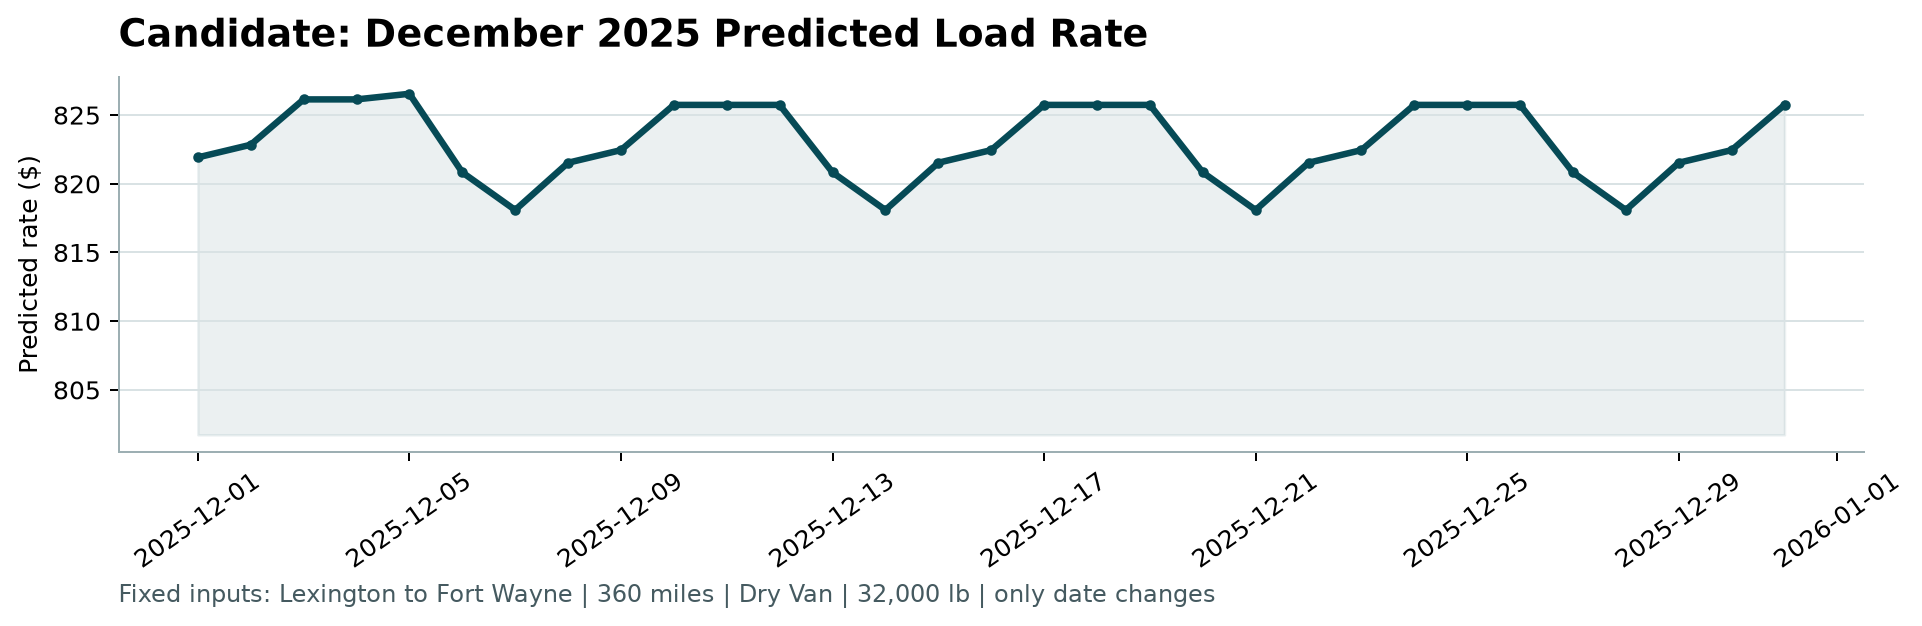

December price range: $818.09 to $826.55
Distinct rounded prices: 9


In [3]:
scorer_output = run_scorer(ROOT, checks)
print(scorer_output)
display(Image(filename=str(ROOT / 'scorer_results/candidate_december.png')))
print(f'December price range: ${december_predictions.predicted_rate.min():,.2f} to ${december_predictions.predicted_rate.max():,.2f}')
print('Distinct rounded prices:', december_predictions.predicted_rate.nunique())

### Interpret the chart carefully

Only the date changes for this fixed load. The small variation reflects the calendar features learned from January-October. Trees cannot extrapolate an unseen time trend, and the labeled data has no December observations. The curve does not prove the model learned holiday pricing. No artificial holiday adjustment was added.

## 3. Rebuild the report

The PDF explains data quality, features, chronological splits, the three model results, limitations and the exact scorer-generated December chart. It reads the saved measurement tables, so it does not rerun model selection or overwrite earlier results.

In [4]:
report_path = build_report(ROOT)
reader = PdfReader(report_path)
report_text = '\n'.join(page.extract_text() for page in reader.pages)
assert len(reader.pages) == 5
assert all(term in report_text for term in ['28,806', '9,671', '9,523', '$128.08', '$818.09', '$826.55'])
print('PDF report:', report_path)
print('Pages:', len(reader.pages))
display(FileLink(str(report_path)))

PDF report:

 C:\Users\default.LAPTOP-H1OG6SJ2\Desktop\Projects\spotter\output\pdf\freight_rate_report.pdf
Pages: 5


C:\Users\default.LAPTOP-H1OG6SJ2\Desktop\Projects\spotter\output\pdf\freight_rate_report.pdf

## 4. Verify preserved work and output hashes

All supplied CSVs, previous model/evaluation artifacts and the protected assessment README must be unchanged. The saved JSON records the final model hash, input hashes, output hashes and scorer checks.

In [5]:
assert source_hashes(ROOT) == source_before
if readme_before is not None:
    assert sha256(readme_path) == readme_before
assert all(sha256(path) == digest for path, digest in protected.items())
assert sha256(ROOT / 'validation_predictions.csv') == sha256(ROOT / 'validation-predictions.csv')
assert all(checks['checks'].values())
display(pd.DataFrame([{'check':name, 'passed':passed} for name, passed in checks['checks'].items()]))
display(pd.DataFrame([{'file':name, 'sha256':digest} for name,digest in checks['output_sha256'].items()]))
print('Complete: predictions, official chart and PDF report generated; protected inputs and earlier work unchanged.')

,check,passed
0,schema_ids_and_values_valid,True
1,template_order_preserved,True
2,december_input_values_preserved,True
3,original_csvs_unchanged,True
4,readme_spotter_unchanged,True
5,official_scorer_passed,True


,file,sha256
0,validation_predictions.csv,d870496610c781065b69b2db1d0479b2b55d6a67e1401b...
1,december_predictions.csv,5b29a160a7ff5a1e0c47e5c7bb015980df57e129b0eb84...
2,scorer_results/candidate_december.png,1071cf94a74dd94b50f9046b478e891edb9cad727f994c...


Complete: predictions, official chart and PDF report generated; protected inputs and earlier work unchanged.


## Delivery

Submit the GitHub repository link, `validation_predictions.csv`, the PDF under `output/pdf/`, and the required 2-3 minute Loom link. The December CSV and chart are also saved for inspection and reproduction. The report's performance figures refer to local evaluation, not the final hidden-target submission.